# Global Water Consumption Analysis

### Team Project — BUSN / DASC

Objective:
Analyze global water consumption trends and extract insights for decision-making.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
pip install matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [6]:
df = pd.read_csv("water.csv")
df.head()

,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,Argentina,2000,481.490000,235.431429,48.550000,20.844286,30.100000,1288.698571,3.255714,Moderate
1,Argentina,2001,455.063000,299.551000,48.465000,26.943000,22.550000,1371.729000,3.120000,Moderate
2,Argentina,2002,482.749231,340.124615,50.375385,29.042308,23.349231,1590.305385,2.733846,Moderate
3,Argentina,2003,452.660000,326.756667,49.086667,30.476000,24.440000,1816.012667,2.708000,Moderate
4,Argentina,2004,634.566000,230.346000,38.670000,36.670000,23.924000,815.998000,1.902000,Moderate


In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Country                                         500 non-null    str    
 1   Year                                            500 non-null    int64  
 2   Total Water Consumption (Billion Cubic Meters)  500 non-null    float64
 3   Per Capita Water Use (Liters per Day)           500 non-null    float64
 4   Agricultural Water Use (%)                      500 non-null    float64
 5   Industrial Water Use (%)                        500 non-null    float64
 6   Household Water Use (%)                         500 non-null    float64
 7   Rainfall Impact (Annual Precipitation in mm)    500 non-null    float64
 8   Groundwater Depletion Rate (%)                  500 non-null    float64
 9   Water Scarcity Level                            500 no

,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2012.000000,501.224430,276.004782,50.180829,27.792837,24.832515,1544.824300,2.573037
std,7.218324,96.078937,42.669593,5.566886,4.361660,2.956135,292.786579,0.480630
min,2000.000000,129.636667,111.708333,28.905000,13.276667,13.668333,700.230000,1.300000
25%,2006.000000,441.447385,250.225406,46.513611,25.018000,23.015355,1353.734583,2.235000
50%,2012.000000,502.197154,276.430556,50.318482,27.648539,25.071944,1537.537724,2.555778
75%,2018.000000,563.849594,300.221750,54.061964,30.698333,26.720167,1746.402425,2.887202
max,2024.000000,798.418000,404.350000,66.520000,43.583333,34.202000,2533.678000,4.322000


## Data Understanding

- Dataset contains 500 rows
- Includes country, year, water usage, and environmental factors
- No missing values


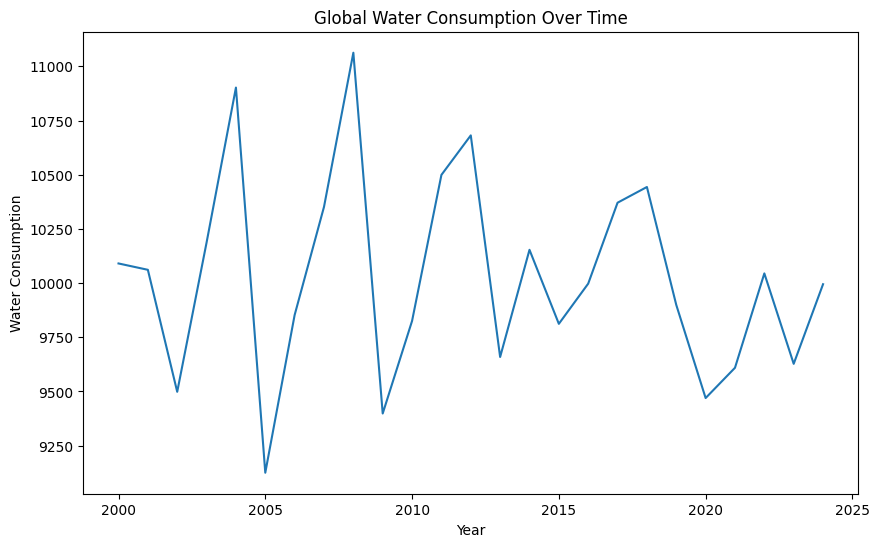

In [8]:
year_consumption = df.groupby("Year")["Total Water Consumption (Billion Cubic Meters)"].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(year_consumption["Year"], year_consumption["Total Water Consumption (Billion Cubic Meters)"])
plt.title("Global Water Consumption Over Time")
plt.xlabel("Year")
plt.ylabel("Water Consumption")
plt.show()

## Insight

Water consumption fluctuates over time, with noticeable peaks around 2008 and 2012.
This suggests possible environmental or economic influences.


In [9]:
top_10 = df.groupby("Country")["Total Water Consumption (Billion Cubic Meters)"].sum().reset_index()
top_10 = top_10.sort_values(by="Total Water Consumption (Billion Cubic Meters)", ascending=False).head(10)

top_10

,Country,Total Water Consumption (Billion Cubic Meters)
0,Argentina,13284.860759
2,Brazil,13263.287436
4,China,13133.596733
19,USA,13058.950844
13,Saudi Arabia,12966.078679
6,Germany,12668.588927
5,France,12596.115707
10,Japan,12585.683217
7,India,12581.662785
14,South Africa,12544.930893


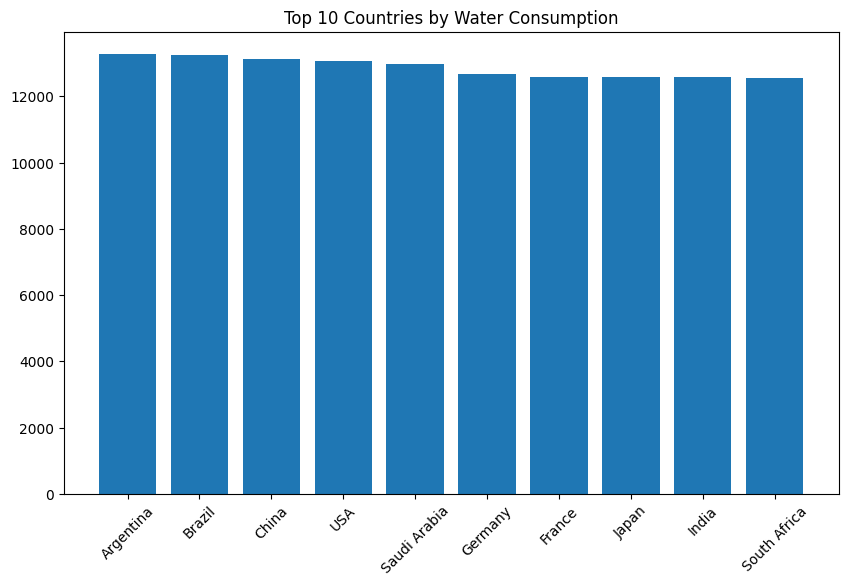

In [10]:
plt.figure(figsize=(10,6))
plt.bar(top_10["Country"], top_10["Total Water Consumption (Billion Cubic Meters)"])
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Water Consumption")
plt.show()

In [11]:
sector_avg = df[[
    "Agricultural Water Use (%)",
    "Industrial Water Use (%)",
    "Household Water Use (%)"
]].mean()

sector_avg

Agricultural Water Use (%)    50.180829
Industrial Water Use (%)      27.792837
Household Water Use (%)       24.832515
dtype: float64

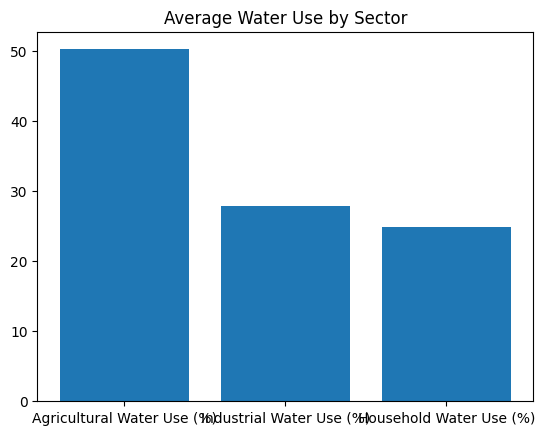

In [12]:
plt.bar(sector_avg.index, sector_avg.values)
plt.title("Average Water Use by Sector")
plt.show()

In [13]:
df["Water Scarcity Level"].value_counts()

Water Scarcity Level
Moderate    360
Low         122
High         18
Name: count, dtype: int64

## Key Findings

- Agriculture consumes the majority of water
- Some countries dominate global usage
- Water scarcity is mostly moderate globally
